# GITT Simulation with PyBaMM

This notebook demonstrates Galvanostatic Intermittent Titration Technique (GITT) simulation using PyBaMM.

## Overview
- **Cell**: Tesla Model 3 Prismatic 160Ah NMC
- **Chemistry**: NMC811 (Nickel Manganese Cobalt)
- **Form Factor**: Prismatic
- **Test Protocol**: 
  1. CCCV charge to 100% SOC
  2. GITT discharge (C/3 pulses, 9 min each, with rest periods)
  3. GITT charge (C/3 pulses, 9 min each, with rest periods)
- **Temperature**: 25°C

## GITT Principle
GITT applies current pulses followed by rest periods to measure:
- OCV at each SOC level
- Overpotential during pulses
- Diffusion coefficient estimation from voltage relaxation

In [16]:
# Import required libraries
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from model_library import run_spmet_manifest

## 1. Load Cell Parameters

Load the cell design from the manifest file.

In [17]:
# Load cell manifest
manifest_path = Path("../cells/Tesla_Model3_Prismatic_160Ah_manifest.json")
material_path = Path("../materials")

with open(manifest_path, 'r') as f:
    cell_design_manifest = json.load(f)
    # Load material data for separator and electrolyte
    for component in ["separator", "electrolyte"]:
        print(f"Loading material data for {component}")
        material_name = cell_design_manifest["cell_design"][component]["material"]["type"]
        material_file_path = material_path / f"{material_name}.json"
        with open(material_file_path, "r") as mf:
            material_data = json.load(mf)
            cell_design_manifest["cell_design"][component]["material"] = material_data

    # Load material data for electrodes
    for component in ["negative_electrode", "positive_electrode"]:
        print(f"Loading material data for {component}")
        material_name = cell_design_manifest["cell_design"][component]["coating"]["formulation"]["primary_active_material"]["name"]
        material_file_path = material_path / f"{material_name}.json"
        with open(material_file_path, "r") as mf:
            material_data = json.load(mf)
            cell_design_manifest["cell_design"][component]["material"] = material_data

# ============================================================================
# FITTED PARAMETERS FROM EXPERIMENTAL DATA
# ============================================================================
cell_design_manifest["cell_design"]["negative_electrode"]["coating"]["bruggeman_coefficient"] = {
    "value": 1.5,
    "unit": "1"
}
cell_design_manifest["cell_design"]["positive_electrode"]["coating"]["bruggeman_coefficient"] = {
    "value": 1.5,
    "unit": "1"
}

# Extract cell parameters
nominal_capacity_Ah = cell_design_manifest['kpis']['nominal_capacity']['value']
upper_voltage_cutoff = cell_design_manifest["cell_design"]["upper_voltage_cutoff"]["value"]
lower_voltage_cutoff = cell_design_manifest["cell_design"]["lower_voltage_cutoff"]["value"]

print(f"\nCell: {cell_design_manifest['metadata']['name']}")
print(f"Capacity: {nominal_capacity_Ah} Ah")
print(f"Voltage range: {lower_voltage_cutoff} - {upper_voltage_cutoff} V")

Loading material data for separator
Loading material data for electrolyte
Loading material data for negative_electrode
Loading material data for positive_electrode

Cell: Tesla Model3 Prismatic 160Ah
Capacity: 161.099 Ah
Voltage range: 2.5 - 3.65 V


## 2. Define GITT Test Protocol

GITT protocol:
- **Current**: C/3 (discharge and charge)
- **Pulse duration**: 9 minutes (540 seconds)
- **Rest duration**: 60 minutes (for OCV equilibration)
- **Sequence**: 
  1. Start at 100% SOC (CCCV charge)
  2. Discharge pulses until lower voltage cutoff
  3. Charge pulses until upper voltage cutoff

In [18]:
# ============================================================================
# GITT TEST PARAMETERS
# ============================================================================
c_rate = 1/3  # C/3
pulse_duration_s = 9 * 60  # 9 minutes in seconds
rest_duration_s = 60 * 60  # 60 minutes rest for OCV equilibration
temperature_K = 298.15  # 25°C

# Calculate current
pulse_current_A = nominal_capacity_Ah * c_rate
print(f"Pulse current: {pulse_current_A:.2f} A (C/{1/c_rate:.0f})")
print(f"Pulse duration: {pulse_duration_s/60:.0f} minutes")
print(f"Rest duration: {rest_duration_s/60:.0f} minutes")

# Calculate approximate SOC change per pulse
# Delta_SOC = (I * t) / Q = c_rate * (t/3600)
delta_soc_per_pulse = c_rate * (pulse_duration_s / 3600)
print(f"SOC change per pulse: ~{delta_soc_per_pulse*100:.1f}%")

# Number of pulses needed (approximate)
n_discharge_pulses = int(1.0 / delta_soc_per_pulse) + 1
n_charge_pulses = int(1.0 / delta_soc_per_pulse) + 1
print(f"Estimated discharge pulses: ~{n_discharge_pulses}")
print(f"Estimated charge pulses: ~{n_charge_pulses}")

Pulse current: 53.70 A (C/3)
Pulse duration: 9 minutes
Rest duration: 60 minutes
SOC change per pulse: ~5.0%
Estimated discharge pulses: ~21
Estimated charge pulses: ~21


## 3. Build GITT Experiment Sequence

Create PyBaMM experiment strings for the full GITT protocol.

In [19]:
# Build experiment sequence
experiments = []
labels = []

# ============================================================================
# PHASE 1: CCCV Charge to 100% SOC (separate CC and CV steps)
# ============================================================================
# CC charge
experiments.append(f"Charge at {c_rate}C until {upper_voltage_cutoff} V")
labels.append("CC_charge")

# CV hold
experiments.append(f"Hold at {upper_voltage_cutoff} V until C/20")
labels.append("CV_hold")

# Rest after initial charge
experiments.append(f"Rest for {rest_duration_s} seconds")
labels.append("Rest_initial")

# ============================================================================
# PHASE 2: GITT Discharge
# ============================================================================
for i in range(n_discharge_pulses):
    # Discharge pulse
    pulse_exp = f"Discharge at {c_rate}C for {pulse_duration_s} seconds or until {lower_voltage_cutoff} V"
    experiments.append(pulse_exp)
    labels.append(f"DCH_pulse_{i+1}")
    
    # Rest period
    rest_exp = f"Rest for {rest_duration_s} seconds"
    experiments.append(rest_exp)
    labels.append(f"DCH_rest_{i+1}")

# ============================================================================
# PHASE 3: GITT Charge
# ============================================================================
for i in range(n_charge_pulses):
    # Charge pulse
    pulse_exp = f"Charge at {c_rate}C for {pulse_duration_s} seconds or until {upper_voltage_cutoff} V"
    experiments.append(pulse_exp)
    labels.append(f"CHG_pulse_{i+1}")
    
    # Rest period
    rest_exp = f"Rest for {rest_duration_s} seconds"
    experiments.append(rest_exp)
    labels.append(f"CHG_rest_{i+1}")

print(f"Total experiment steps: {len(experiments)}")
print(f"\nFirst 12 steps:")
for i, (exp, lbl) in enumerate(zip(experiments[:12], labels[:12])):
    print(f"  {i+1}. [{lbl}] {exp[:60]}{'...' if len(exp) > 60 else ''}")

Total experiment steps: 87

First 12 steps:
  1. [CC_charge] Charge at 0.3333333333333333C until 3.65 V
  2. [CV_hold] Hold at 3.65 V until C/20
  3. [Rest_initial] Rest for 3600 seconds
  4. [DCH_pulse_1] Discharge at 0.3333333333333333C for 540 seconds or until 2....
  5. [DCH_rest_1] Rest for 3600 seconds
  6. [DCH_pulse_2] Discharge at 0.3333333333333333C for 540 seconds or until 2....
  7. [DCH_rest_2] Rest for 3600 seconds
  8. [DCH_pulse_3] Discharge at 0.3333333333333333C for 540 seconds or until 2....
  9. [DCH_rest_3] Rest for 3600 seconds
  10. [DCH_pulse_4] Discharge at 0.3333333333333333C for 540 seconds or until 2....
  11. [DCH_rest_4] Rest for 3600 seconds
  12. [DCH_pulse_5] Discharge at 0.3333333333333333C for 540 seconds or until 2....


## 4. Run GITT Simulation

Execute the full GITT protocol using the SPMeT model.

In [20]:
# GITT configuration
gitt_config = {
    "ambient_temperature": temperature_K,
    "initial_temperature": temperature_K,
    "initial_soc": 0.1,  # Start low, will charge to 100% first
    "upper_voltage_cutoff": upper_voltage_cutoff,
    "lower_voltage_cutoff": lower_voltage_cutoff,
    "contact_resistance": 0.0001,
    "total_heat_transfer_coefficient": 10,
    "cooling_surface_area": 0.01,
    "period": "10 second",  # 10s resolution for long experiment
    "experiments": experiments,
    "experiment_labels": labels,
}

print("Running GITT simulation...")
print("(This may take several minutes due to the long experiment sequence)")
results = run_spmet_manifest(cell_design_manifest=cell_design_manifest, simulation_config=gitt_config)

Running GITT simulation...
(This may take several minutes due to the long experiment sequence)

Building model parameters from manifest...
  Positive electrode: sto_0=0.9990, sto_100=0.0010
  Negative electrode: sto_0=0.0539, sto_100=0.9959
  OCV at 0% cell SOC: 2.514 - 1.001 = 1.513 V
  OCV at 100% cell SOC: 3.838 - 0.009 = 3.829 V
  Parameters loaded

CAPACITY CALIBRATION
Target capacity: 161.10 Ah
Charge current: 53.70 A (C/3), Discharge current: 16.11 A (C/10)
Upper voltage: 3.65 V, Lower voltage: 2.5 V
Nominal capacity in params: 161.10 Ah
Pos sto limits: min=0.0010, max=0.9990
Neg sto limits: min=0.0539, max=0.9959
PyBaMM calculated cell capacity: 161.10 Ah
Experiment steps:
  1. Rest, Charge at 0.1C until 3.65 V, Hold at 3.65 V for 2 hours or until C/50
  2. Rest
  3. Discharge at 0.1C for 15 hours or until 2.5 V
  4. Rest
Convergence tolerance: 0.010%
--------------------------------------------------------------------------------
Iteration  1: Capacity =  27.60 Ah, Error = 82.

## 5. Post-Processing: Extract GITT Metrics

Extract key metrics from each pulse:
- OCV before pulse (equilibrium voltage)
- Voltage at end of pulse
- Overpotential (IR drop + polarization)
- SOC at each step

In [21]:
# Separate results by phase
successful_results = [r for r in results if r['success']]
print(f"Successful experiments: {len(successful_results)}/{len(results)}")

# Extract discharge and charge pulse data
discharge_pulses = []
discharge_rests = []
charge_pulses = []
charge_rests = []

for r in successful_results:
    label = r['experiment_label']
    if label.startswith('DCH_pulse'):
        discharge_pulses.append(r)
    elif label.startswith('DCH_rest'):
        discharge_rests.append(r)
    elif label.startswith('CHG_pulse'):
        charge_pulses.append(r)
    elif label.startswith('CHG_rest'):
        charge_rests.append(r)

print(f"\nDischarge pulses: {len(discharge_pulses)}")
print(f"Discharge rests: {len(discharge_rests)}")
print(f"Charge pulses: {len(charge_pulses)}")
print(f"Charge rests: {len(charge_rests)}")

Successful experiments: 87/87

Discharge pulses: 21
Discharge rests: 21
Charge pulses: 21
Charge rests: 21


In [22]:
# Extract GITT metrics from discharge phase
gitt_discharge_metrics = []

for i, (pulse, rest) in enumerate(zip(discharge_pulses, discharge_rests)):
    # OCV = voltage at end of rest (before pulse)
    # For first pulse, use initial voltage
    if i == 0:
        # Find the rest before first discharge pulse
        initial_rest = [r for r in successful_results if r['experiment_label'] == 'Rest_initial']
        if initial_rest:
            ocv_before = float(initial_rest[0]['voltage_V'][-1])
        else:
            ocv_before = float(pulse['voltage_V'][0])
    else:
        # OCV from previous rest period end
        prev_rest = discharge_rests[i-1]
        ocv_before = float(prev_rest['voltage_V'][-1])
    
    # Voltage at end of pulse
    v_end_pulse = float(pulse['voltage_V'][-1])
    
    # OCV after rest (equilibrium)
    ocv_after = float(rest['voltage_V'][-1])
    
    # Overpotential during pulse
    overpotential = ocv_before - v_end_pulse
    
    # Capacity discharged in this pulse
    capacity_Ah = float(pulse['capacity_Ah'][-1] - pulse['capacity_Ah'][0])
    
    # Estimate SOC (cumulative capacity / nominal capacity)
    cumulative_cap = sum([float(p['capacity_Ah'][-1] - p['capacity_Ah'][0]) for p in discharge_pulses[:i+1]])
    soc_estimate = 1.0 - (cumulative_cap / nominal_capacity_Ah)
    
    gitt_discharge_metrics.append({
        'pulse_num': i + 1,
        'soc_estimate': soc_estimate,
        'ocv_before_V': ocv_before,
        'v_end_pulse_V': v_end_pulse,
        'ocv_after_V': ocv_after,
        'overpotential_V': overpotential,
        'capacity_Ah': capacity_Ah,
    })

if gitt_discharge_metrics:
    df_dch = pd.DataFrame(gitt_discharge_metrics)
    print("\nGITT Discharge Metrics:")
    print(df_dch.to_string(index=False, float_format=lambda x: f'{x:.4f}'))


GITT Discharge Metrics:
 pulse_num  soc_estimate  ocv_before_V  v_end_pulse_V  ocv_after_V  overpotential_V  capacity_Ah
         1        0.9500        3.1906         2.8604       3.1906           0.3302       8.0549
         2        0.9000        3.1906         2.8604       3.1906           0.3302       8.0549
         3        0.8500        3.1906         2.8604       3.1906           0.3302       8.0549
         4        0.8000        3.1906         2.8604       3.1906           0.3302       8.0549
         5        0.7500        3.1906         2.8604       3.1906           0.3302       8.0549
         6        0.7000        3.1906         2.8604       3.1906           0.3302       8.0549
         7        0.6500        3.1906         2.8604       3.1906           0.3302       8.0549
         8        0.6000        3.1906         2.8604       3.1906           0.3302       8.0549
         9        0.5500        3.1906         2.8604       3.1906           0.3302       8.0549
     

In [23]:
# Extract GITT metrics from charge phase
gitt_charge_metrics = []

for i, (pulse, rest) in enumerate(zip(charge_pulses, charge_rests)):
    # OCV from previous rest
    if i == 0:
        # Use last discharge rest
        if discharge_rests:
            ocv_before = float(discharge_rests[-1]['voltage_V'][-1])
        else:
            ocv_before = float(pulse['voltage_V'][0])
    else:
        prev_rest = charge_rests[i-1]
        ocv_before = float(prev_rest['voltage_V'][-1])
    
    # Voltage at end of pulse
    v_end_pulse = float(pulse['voltage_V'][-1])
    
    # OCV after rest
    ocv_after = float(rest['voltage_V'][-1])
    
    # Overpotential (charge: pulse voltage > OCV)
    overpotential = v_end_pulse - ocv_before
    
    # Capacity charged
    capacity_Ah = abs(float(pulse['capacity_Ah'][-1] - pulse['capacity_Ah'][0]))
    
    # Estimate SOC
    cumulative_cap = sum([abs(float(p['capacity_Ah'][-1] - p['capacity_Ah'][0])) for p in charge_pulses[:i+1]])
    # Start from ~0% SOC after discharge
    soc_estimate = cumulative_cap / nominal_capacity_Ah
    
    gitt_charge_metrics.append({
        'pulse_num': i + 1,
        'soc_estimate': soc_estimate,
        'ocv_before_V': ocv_before,
        'v_end_pulse_V': v_end_pulse,
        'ocv_after_V': ocv_after,
        'overpotential_V': overpotential,
        'capacity_Ah': capacity_Ah,
    })

if gitt_charge_metrics:
    df_chg = pd.DataFrame(gitt_charge_metrics)
    print("\nGITT Charge Metrics:")
    print(df_chg.to_string(index=False, float_format=lambda x: f'{x:.4f}'))


GITT Charge Metrics:
 pulse_num  soc_estimate  ocv_before_V  v_end_pulse_V  ocv_after_V  overpotential_V  capacity_Ah
         1        0.0500        3.1906         3.2477       3.1906           0.0570       8.0549
         2        0.1000        3.1906         3.2477       3.1906           0.0570       8.0549
         3        0.1500        3.1906         3.2477       3.1906           0.0570       8.0549
         4        0.2000        3.1906         3.2477       3.1906           0.0570       8.0549
         5        0.2500        3.1906         3.2477       3.1906           0.0570       8.0549
         6        0.3000        3.1906         3.2477       3.1906           0.0570       8.0549
         7        0.3500        3.1906         3.2477       3.1906           0.0570       8.0549
         8        0.4000        3.1906         3.2477       3.1906           0.0570       8.0549
         9        0.4500        3.1906         3.2477       3.1906           0.0570       8.0549
        

## 6. Visualize GITT Results

In [24]:
# Concatenate all time series for full voltage profile
all_time = []
all_voltage = []
all_current = []
time_offset = 0

for r in successful_results:
    t = r['time_s'] - r['time_s'][0] + time_offset
    all_time.extend(t)
    all_voltage.extend(r['voltage_V'])
    all_current.extend(r['current_A'])
    time_offset = t[-1]

all_time = np.array(all_time)
all_voltage = np.array(all_voltage)
all_current = np.array(all_current)

print(f"Total experiment duration: {all_time[-1]/3600:.1f} hours")

Total experiment duration: 63.2 hours


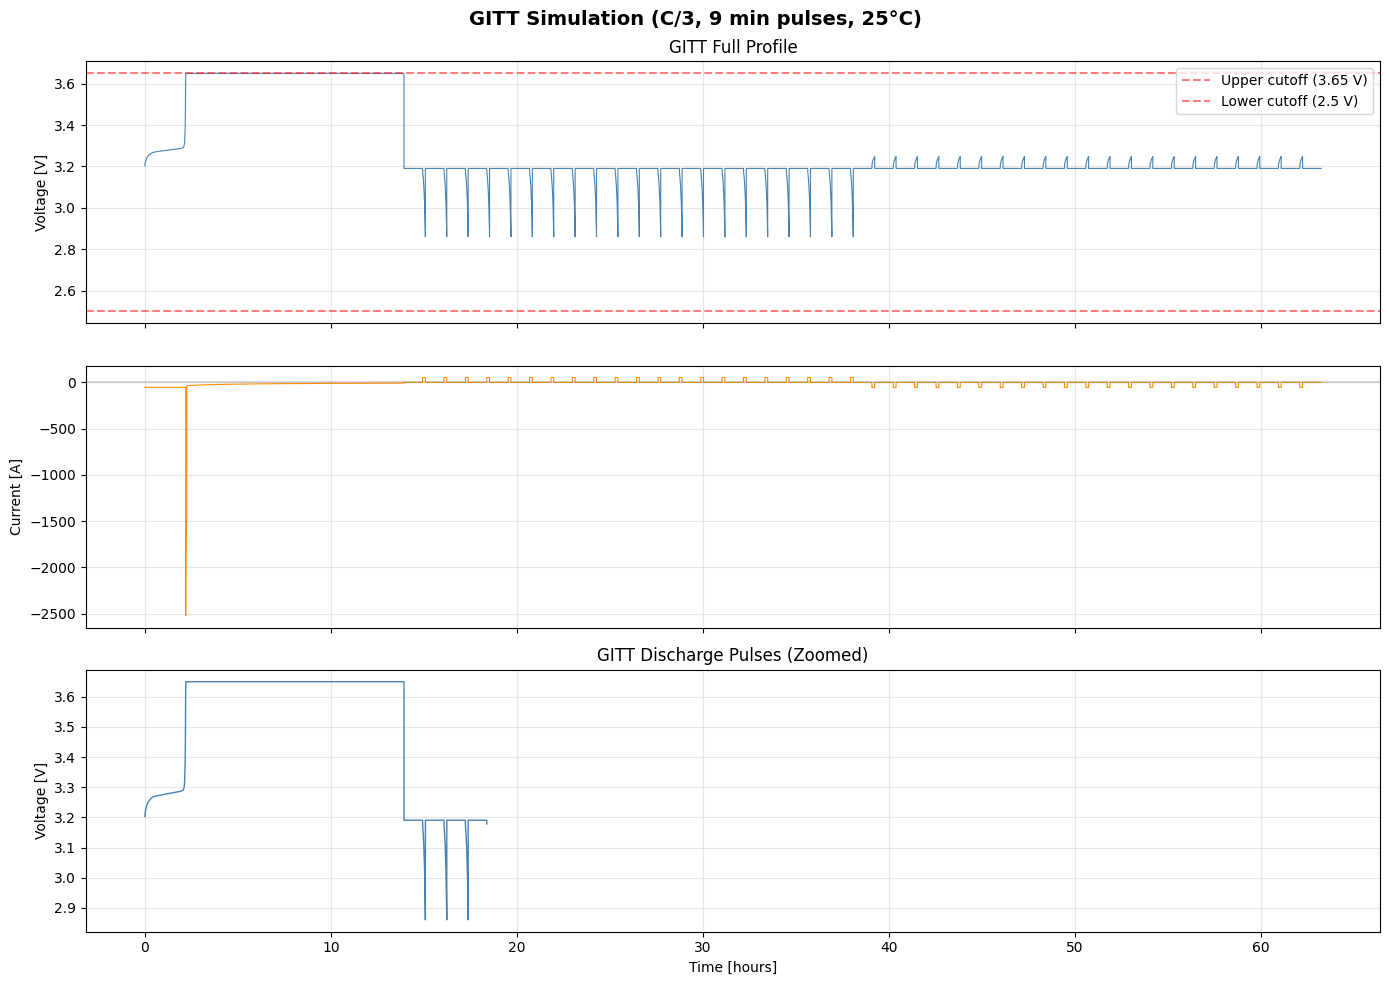

In [25]:
# Plot full GITT profile
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Plot 1: Voltage vs Time
ax1 = axes[0]
ax1.plot(all_time/3600, all_voltage, linewidth=0.8, color='steelblue')
ax1.set_ylabel('Voltage [V]')
ax1.set_title('GITT Full Profile')
ax1.grid(True, alpha=0.3)
ax1.axhline(y=upper_voltage_cutoff, color='red', linestyle='--', alpha=0.5, label=f'Upper cutoff ({upper_voltage_cutoff} V)')
ax1.axhline(y=lower_voltage_cutoff, color='red', linestyle='--', alpha=0.5, label=f'Lower cutoff ({lower_voltage_cutoff} V)')
ax1.legend(loc='upper right')

# Plot 2: Current vs Time
ax2 = axes[1]
ax2.plot(all_time/3600, all_current, linewidth=0.8, color='darkorange')
ax2.set_ylabel('Current [A]')
ax2.grid(True, alpha=0.3)
ax2.axhline(y=0, color='gray', linestyle='-', alpha=0.3)

# Plot 3: Zoomed view of a few pulses
ax3 = axes[2]
# Find time range for first 3 discharge pulses
if len(discharge_pulses) >= 3:
    t_start = 0
    # Find end of 3rd discharge rest
    t_end_idx = 0
    pulse_count = 0
    for i, r in enumerate(successful_results):
        if r['experiment_label'].startswith('DCH_rest'):
            pulse_count += 1
            if pulse_count == 3:
                # Calculate time offset to this point
                t_end = sum([sr['time_s'][-1] - sr['time_s'][0] for sr in successful_results[:i+1]])
                break
    else:
        t_end = all_time[-1]
    
    mask = (all_time >= t_start) & (all_time <= t_end)
    ax3.plot(all_time[mask]/3600, all_voltage[mask], linewidth=1, color='steelblue')
    ax3.set_xlabel('Time [hours]')
    ax3.set_ylabel('Voltage [V]')
    ax3.set_title('GITT Discharge Pulses (Zoomed)')
    ax3.grid(True, alpha=0.3)
else:
    ax3.set_xlabel('Time [hours]')
    ax3.text(0.5, 0.5, 'Insufficient data for zoom', ha='center', va='center', transform=ax3.transAxes)

plt.suptitle(f'GITT Simulation (C/{1/c_rate:.0f}, {pulse_duration_s/60:.0f} min pulses, {temperature_K-273.15:.0f}°C)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

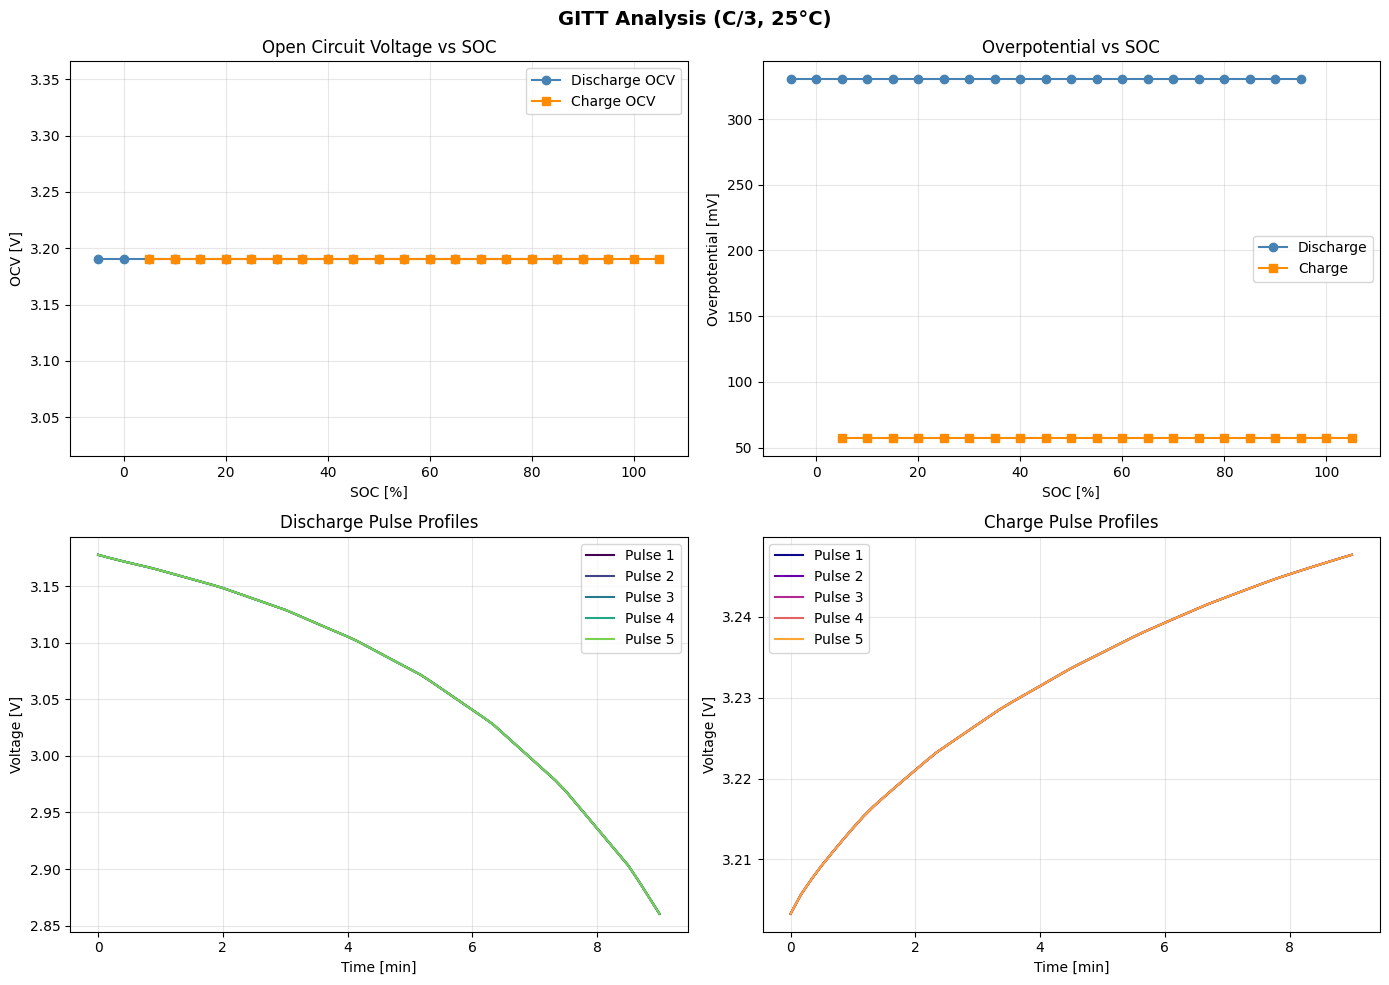

In [26]:
# Plot OCV vs SOC from GITT data
if gitt_discharge_metrics and gitt_charge_metrics:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Plot 1: OCV vs SOC
    ax1 = axes[0, 0]
    df_dch = pd.DataFrame(gitt_discharge_metrics)
    df_chg = pd.DataFrame(gitt_charge_metrics)
    
    ax1.plot(df_dch['soc_estimate']*100, df_dch['ocv_after_V'], 'o-', 
             markersize=6, linewidth=1.5, color='steelblue', label='Discharge OCV')
    ax1.plot(df_chg['soc_estimate']*100, df_chg['ocv_after_V'], 's-', 
             markersize=6, linewidth=1.5, color='darkorange', label='Charge OCV')
    ax1.set_xlabel('SOC [%]')
    ax1.set_ylabel('OCV [V]')
    ax1.set_title('Open Circuit Voltage vs SOC')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Overpotential vs SOC
    ax2 = axes[0, 1]
    ax2.plot(df_dch['soc_estimate']*100, df_dch['overpotential_V']*1000, 'o-',
             markersize=6, linewidth=1.5, color='steelblue', label='Discharge')
    ax2.plot(df_chg['soc_estimate']*100, df_chg['overpotential_V']*1000, 's-',
             markersize=6, linewidth=1.5, color='darkorange', label='Charge')
    ax2.set_xlabel('SOC [%]')
    ax2.set_ylabel('Overpotential [mV]')
    ax2.set_title('Overpotential vs SOC')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Plot 3: Pulse voltage profiles (discharge)
    ax3 = axes[1, 0]
    colors = plt.cm.viridis(np.linspace(0, 0.8, min(len(discharge_pulses), 5)))
    for i, pulse in enumerate(discharge_pulses[:5]):
        t = pulse['time_s'] - pulse['time_s'][0]
        ax3.plot(t/60, pulse['voltage_V'], linewidth=1.5, color=colors[i],
                 label=f"Pulse {i+1}")
    ax3.set_xlabel('Time [min]')
    ax3.set_ylabel('Voltage [V]')
    ax3.set_title('Discharge Pulse Profiles')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # Plot 4: Pulse voltage profiles (charge)
    ax4 = axes[1, 1]
    colors = plt.cm.plasma(np.linspace(0, 0.8, min(len(charge_pulses), 5)))
    for i, pulse in enumerate(charge_pulses[:5]):
        t = pulse['time_s'] - pulse['time_s'][0]
        ax4.plot(t/60, pulse['voltage_V'], linewidth=1.5, color=colors[i],
                 label=f"Pulse {i+1}")
    ax4.set_xlabel('Time [min]')
    ax4.set_ylabel('Voltage [V]')
    ax4.set_title('Charge Pulse Profiles')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    plt.suptitle(f'GITT Analysis (C/{1/c_rate:.0f}, {temperature_K-273.15:.0f}°C)',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("Insufficient GITT data for plotting.")

## 7. Export Results

In [27]:
# Export GITT metrics to CSV
if gitt_discharge_metrics:
    df_dch_export = pd.DataFrame(gitt_discharge_metrics)
    # df_dch_export.to_csv('gitt_discharge_metrics.csv', index=False)
    print("Discharge metrics ready for export (uncomment to save)")

if gitt_charge_metrics:
    df_chg_export = pd.DataFrame(gitt_charge_metrics)
    # df_chg_export.to_csv('gitt_charge_metrics.csv', index=False)
    print("Charge metrics ready for export (uncomment to save)")

# Export full time series
df_full = pd.DataFrame({
    'time_s': all_time,
    'voltage_V': all_voltage,
    'current_A': all_current,
})
# df_full.to_csv('gitt_full_timeseries.csv', index=False)
print(f"Full time series: {len(df_full)} data points ready for export")

Discharge metrics ready for export (uncomment to save)
Charge metrics ready for export (uncomment to save)
Full time series: 22850 data points ready for export
